## Principal Component Analysis (PCA) 
- **Goal:** Investigate features for potential candidate for next iteration of modeling

array([0.52140067, 0.47859933])

Text(0.5, 1.0, 'PCA Explained Variance')

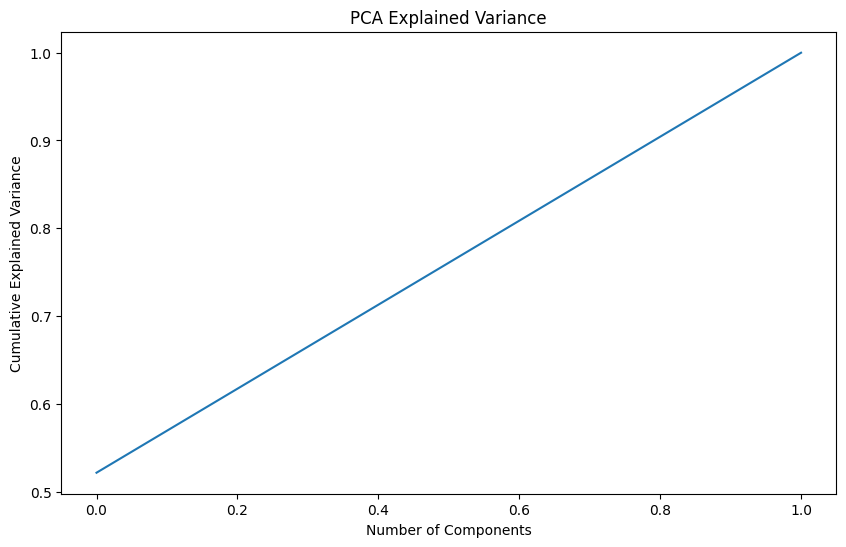

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

construction_df = pd.read_csv(Path.cwd().parent / "src" / "data" / "processed" / "construction_with_risk_proxy.csv")

# Using Shape__Length and FISCALYR for initial exploration
features = ["Shape__Length", "FISCALYR"]
X = construction_df[features]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

plt.figure(figsize=(10, 6))
# Plotting the cumulative explained variance
plt.plot(np.cumsum(pca.explained_variance_ratio_))
# Display the explained variance ratio for each component
display(pca.explained_variance_ratio_)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')

### Interpretation

PCA results show that variance is relatively balanced across the selected features, with no single dominant component
- `Shape__Length` explains ~52% of variance
- `FISCALYR` ~48% variance

> This suggests that the underlying feature space is not inherently dominated by a single variable.

However, earlier modeling results showed near-perfect predictive performance due to the construction of the target variable (`risk_proxy`), which is heavily influenced by normalized segment length.

### Conclusion

> PCA confirms that the observed model performance is driven by target engineering rather than intrinsic structure in the data.